# Introduction to K-Means Clustering

K-Means is an unsupervised machine learning algorithm that partitions data into `k` predefined clusters. It groups similar data points by minimizing the distance between points and their assigned cluster centroid. The algorithm iteratively assigns points to the nearest centroid and updates centroids until convergence. Widely used for tasks like customer segmentation and image compression, it assumes spherical clusters and requires specifying `k` in advance.

#Customer Segmentation: Seeing Natural Clusters in Your Data

##1. Setup and Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Load the dataset
!curl -L -o facebook_live_sellers.csv https://archive.ics.uci.edu/static/public/488/data.csv
data = pd.read_csv('facebook_live_sellers.csv')

# Display the first few rows to understand the structure
print("Dataset Preview:")
print(data.head())

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  337k    0  337k    0     0   355k      0 --:--:-- --:--:-- --:--:--  355k
Dataset Preview:
   status_id status_type status_published  num_reactions  num_comments  \
0          1       video   4/22/2018 6:00            529           512   
1          2       photo  4/21/2018 22:45            150             0   
2          3       video   4/21/2018 6:17            227           236   
3          4       photo   4/21/2018 2:29            111             0   
4          5       photo   4/18/2018 3:22            213             0   

   num_shares  num_likes  num_loves  num_wows  num_hahas  num_sads  num_angrys  
0         262        432         92         3          1         1           0  
1           0        150          0         0          0         0           0  
2          57        204         21         1          1  

##2. Initial Data Exploration and Visualization

In [3]:
# Check basic information about the dataset
print("\nDataset Information:")
print(data.info())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(data.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_id         7050 non-null   int64 
 1   status_type       7050 non-null   object
 2   status_published  7050 non-null   object
 3   num_reactions     7050 non-null   int64 
 4   num_comments      7050 non-null   int64 
 5   num_shares        7050 non-null   int64 
 6   num_likes         7050 non-null   int64 
 7   num_loves         7050 non-null   int64 
 8   num_wows          7050 non-null   int64 
 9   num_hahas         7050 non-null   int64 
 10  num_sads          7050 non-null   int64 
 11  num_angrys        7050 non-null   int64 
dtypes: int64(10), object(2)
memory usage: 661.1+ KB
None

Missing Values:
status_id           0
status_type         0
status_published    0
num_reactions       0
num_comments        0
num_shares          0
num_likes           

##3. Preparing Data for Clustering

In [4]:
# Select numerical features for clustering
features = data[['num_reactions', 'num_comments', 'num_shares', 'num_likes',
                 'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys']]

# Standardize features (important for K-Means)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Convert to DataFrame for easier handling
scaled_features_df = pd.DataFrame(scaled_features, columns=features.columns)

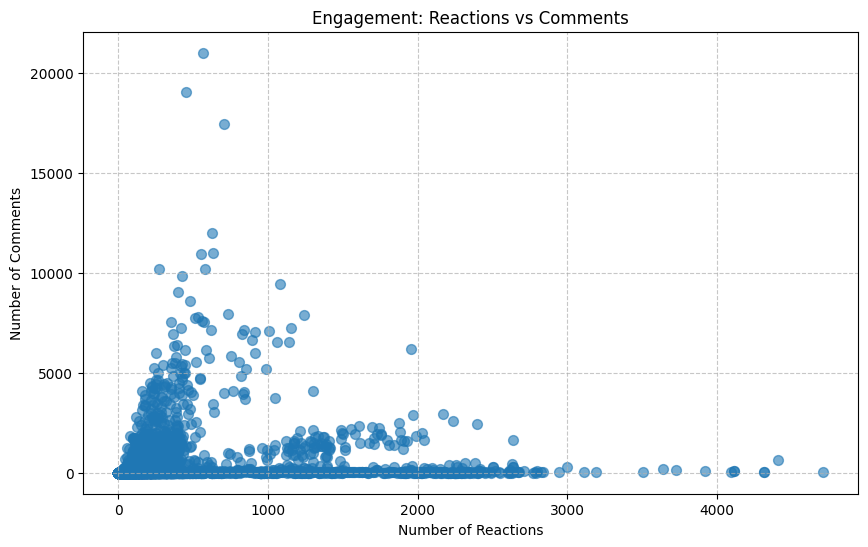

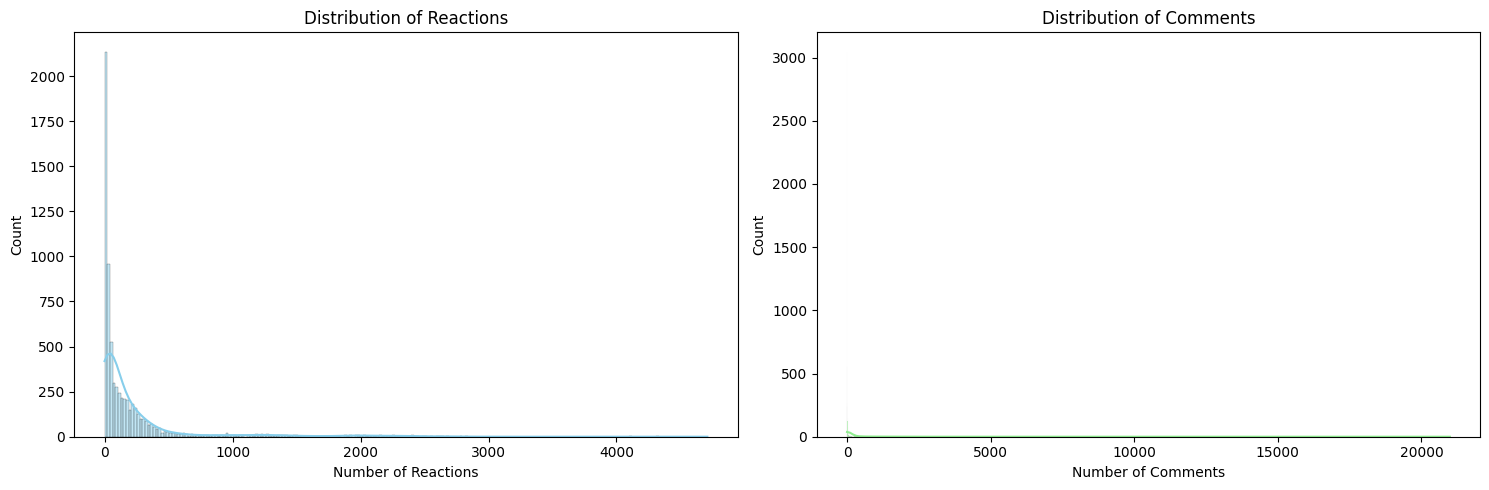

In [5]:
# Create a scatter plot to visualize key engagement metrics
plt.figure(figsize=(10, 6))
plt.scatter(data['num_reactions'], data['num_comments'], alpha=0.6, s=50)
plt.title('Engagement: Reactions vs Comments')
plt.xlabel('Number of Reactions')
plt.ylabel('Number of Comments')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Analyze distributions of key features
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Reactions distribution
sns.histplot(data['num_reactions'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Reactions')
axes[0].set_xlabel('Number of Reactions')

# Comments distribution
sns.histplot(data['num_comments'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Comments')
axes[1].set_xlabel('Number of Comments')

plt.tight_layout()
plt.show()

#Clustering with K-Means: From Code to Customer Insights

##1. Implementing K-Means Clustering

In [6]:
# Apply K-Means clustering with an initial number of clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(scaled_features)

# Add cluster labels to the original data
data['Cluster'] = kmeans.labels_

# Display the updated DataFrame with cluster assignments
print("\nData with Cluster Assignments:")
print(data.head())

# Get the cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers = pd.DataFrame(centers, columns=features.columns)
print("\nCluster Centers:")
print(cluster_centers)


Data with Cluster Assignments:
   status_id status_type status_published  num_reactions  num_comments  \
0          1       video   4/22/2018 6:00            529           512   
1          2       photo  4/21/2018 22:45            150             0   
2          3       video   4/21/2018 6:17            227           236   
3          4       photo   4/21/2018 2:29            111             0   
4          5       photo   4/18/2018 3:22            213             0   

   num_shares  num_likes  num_loves  num_wows  num_hahas  num_sads  \
0         262        432         92         3          1         1   
1           0        150          0         0          0         0   
2          57        204         21         1          1         0   
3           0        111          0         0          0         0   
4           0        204          9         0          0         0   

   num_angrys  Cluster  
0           0        0  
1           0        0  
2           0        0  
3 

##2. Visualizing the Clusters

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


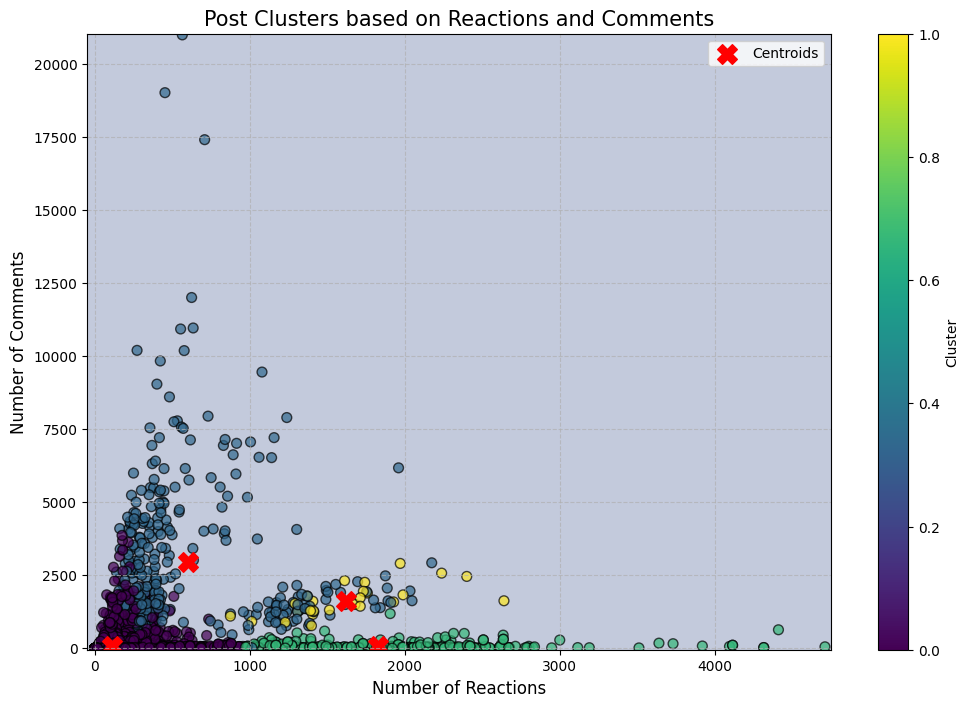

<ipython-input-7-505ac077160c>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='num_reactions', data=data, palette='viridis')
<ipython-input-7-505ac077160c>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='num_comments', data=data, palette='viridis')


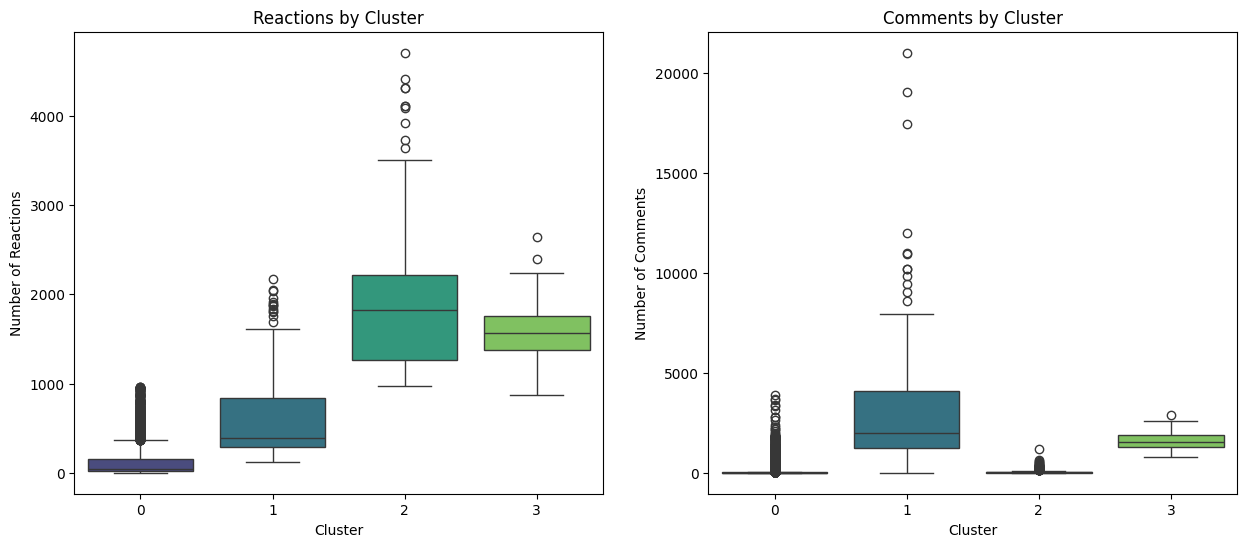

In [7]:
# Create a scatter plot with color-coded clusters and background colors
plt.figure(figsize=(12, 8))

# Create a mesh grid for background colors (using only num_reactions and num_comments)
x_min, x_max = data['num_reactions'].min() - 50, data['num_reactions'].max() + 50
y_min, y_max = data['num_comments'].min() - 50, data['num_comments'].max() + 50
xx, yy = np.meshgrid(np.arange(x_min, x_max, 10), np.arange(y_min, y_max, 10))

# Prepare the mesh grid points for prediction
mesh_points = np.c_[xx.ravel(), yy.ravel()]
# Scale the mesh points using the same scaler (only for num_reactions and num_comments)
mesh_scaled = scaler.transform(np.zeros((mesh_points.shape[0], features.shape[1])))
mesh_scaled[:, [0, 1]] = scaler.fit_transform(mesh_points)[:, :2]  # Only scale reactions and comments
# Predict cluster for each mesh point
Z = kmeans.predict(mesh_scaled)
Z = Z.reshape(xx.shape)

# Plot the background colors
plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)

# Plot the data points
plt.scatter(data['num_reactions'], data['num_comments'],
            c=data['Cluster'], cmap='viridis', s=50, alpha=0.7, edgecolors='k')
plt.scatter(cluster_centers['num_reactions'], cluster_centers['num_comments'],
            c='red', s=200, marker='X', label='Centroids')
plt.title('Post Clusters based on Reactions and Comments', fontsize=15)
plt.xlabel('Number of Reactions', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.colorbar(label='Cluster')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Analyze cluster characteristics
plt.figure(figsize=(15, 6))

# Distribution of Reactions by cluster
plt.subplot(1, 2, 1)
sns.boxplot(x='Cluster', y='num_reactions', data=data, palette='viridis')
plt.title('Reactions by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Reactions')

# Distribution of Comments by cluster
plt.subplot(1, 2, 2)
sns.boxplot(x='Cluster', y='num_comments', data=data, palette='viridis')
plt.title('Comments by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Comments')
plt.show()

#Choosing the Best K with the Elbow Method

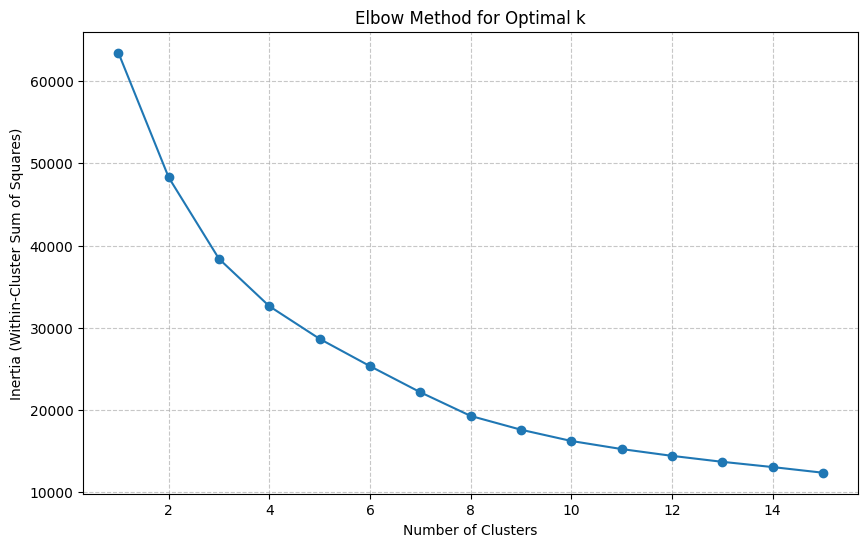

In [8]:
# Elbow method to find optimal number of clusters
inertia = []
k_range = range(1, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

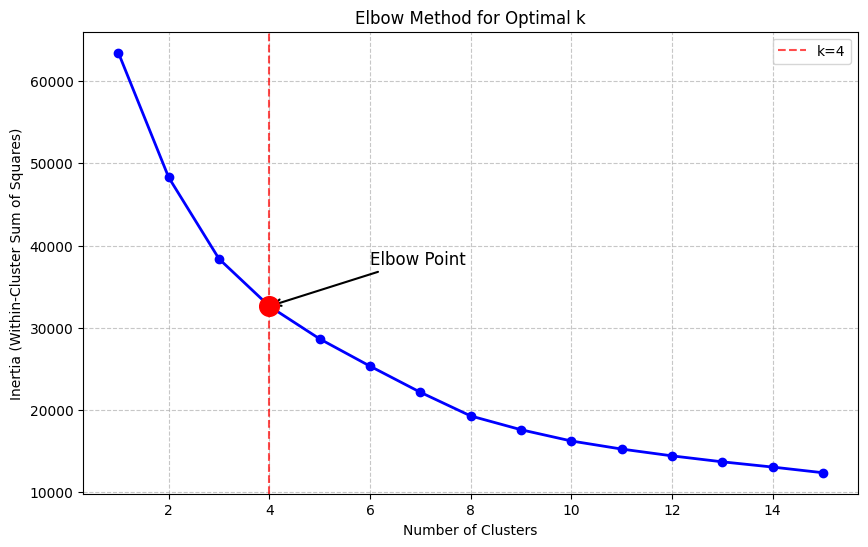

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Elbow method to find optimal number of clusters
inertia = []
k_range = range(1, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-', linewidth=2, color='blue')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight k=4
k_elbow = 4
plt.axvline(x=k_elbow, color='red', linestyle='--', alpha=0.7, label=f'k={k_elbow}')
plt.scatter(k_elbow, inertia[k_elbow-1], color='red', s=200, zorder=5)  # Highlight point at k=4

# Add an arrow and label
plt.annotate('Elbow Point',
             xy=(k_elbow, inertia[k_elbow-1]),  # Point to annotate
             xytext=(k_elbow + 2, inertia[k_elbow-1] + (inertia[0] - inertia[-1]) * 0.1),  # Text position
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
             fontsize=12, color='black')

plt.legend()
plt.show()